Author: Daniel Abadjiev  
Date: October 17, 2025  
Description: A runner notebook for ASICModel.py to try it out. 
Eventually this should be made into a script, or added to a generic script.

In [1]:

import os
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

import ASICModel

2026-06-05 11:44:51.419680: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-05 11:44:51.421410: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-05 11:44:51.460549: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-05 11:44:51.461204: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-05 11:44:52.300498: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

WARN: Unable to import optimizer(s) from expr_templates.py: No module named 'sympy'
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
True
True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
False


2026-06-05 11:44:54.629270: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-06-05 11:44:54.635243: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [2]:
Model1 = ASICModel.ModelASIC(tfRecordFolder="/local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/")
# Model1.buildModel()
# Model1.makeUnquantizedModel()
# Model1.loadTfRecords()
# Model1.makeQuantizedModel()
# Model1.trainModel(epochNumber=10)
Model1.validation_generator

=== Running Complete ASIC Model Pipeline with Quantization Testing ===
All results will be saved to: ASIC Model_results_20260605_114455/
1. Loading TFRecords...
Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized//tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized//tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 162
Validation generator length: 41

2. Testing Non-quantized Model...
2a. Building Unquantized model...
runUnquantized set False, so skipping unquantized model

3. Testing 4-bit Quantized Model...
3a. Creating fresh data generators...
Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized//tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized//tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 162
Validation generator length: 41
I'm not sure that's actually necessary
3b. Building 4-bit quantized model...
Building Model ASIC quantized_4w0i...
Model: "ModelASIC_quantized4"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 z_global (InputLayer)       [(None, 1)]                  0         []                            
                                                                                                  
 y_local (InputLayer)        [(None, 1)]                  0         []                            
                                                                                                  
 concatenate_1 (Concatenate  (None, 2)                    0         ['z_global[0][0]',            
 )                                                                   'y_local[0][0]']             


/home/dabadjiev/miniconda3/envs/miscGithubEnviro/lib/python3.10/site-packages/keras/src/engine/functional.py:639: UserWarning: Input dict contained keys ['x_profile', 'cluster', 'nPix', 'x_local', 'nModule'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


162/162 [==============================] - ETA: 0s - loss: 0.8718 - sparse_categorical_accuracy: 0.6459
[Gradient Monitor] Epoch 0:
  Mean grad norm: 1.20e-01
  Max grad norm: 3.69e-01
  Min grad norm: 6.70e-08


162/162 [==============================] - 18s 111ms/step - loss: 0.8718 - sparse_categorical_accuracy: 0.6459 - val_loss: 0.7329 - val_sparse_categorical_accuracy: 0.7312
✓ ASIC Model quantized_4w0i training completed!

[Gradient Statistics Summary for quantized_4w0i]
  Final mean gradient norm: 1.20e-01
  Final max gradient norm: 3.69e-01
  Final min gradient norm: 6.70e-08
3e. Evaluating 4-bit quantized model...
Evaluating ASIC Model [quantized_4w0i]...
41/41 [==============================] - 4s 88ms/step
<class 'MuC_Smartpix_ML.Model_Classes.SmartPixModel'>
Data rate at fpr 1.0 and threshold [0]
Data rate at fpr 1.0 and threshold [0]
Data rate at fpr 1.0 and threshold [0]
✓ ASIC Model evaluation completed!
  Test Loss: 0.7319
  Test Accuracy: 0.7333
  ROC AUC: 0.7333

  Background Rejection Metrics (Bkg Rej = 1 - FPR):
    @ 90% signal efficiency: Bkg Rej = 0.0000 (FPR = 1.000000), Back Data Accep = 0.1718
    @ 98% signal efficiency: Bkg Rej = 0.0000 (FPR = 1.000000), Back Data A

/home/dabadjiev/miniconda3/envs/miscGithubEnviro/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Training history plot saved to ASIC Model_results_20260605_114455/plots/4bit/ASIC Model_training_history.png


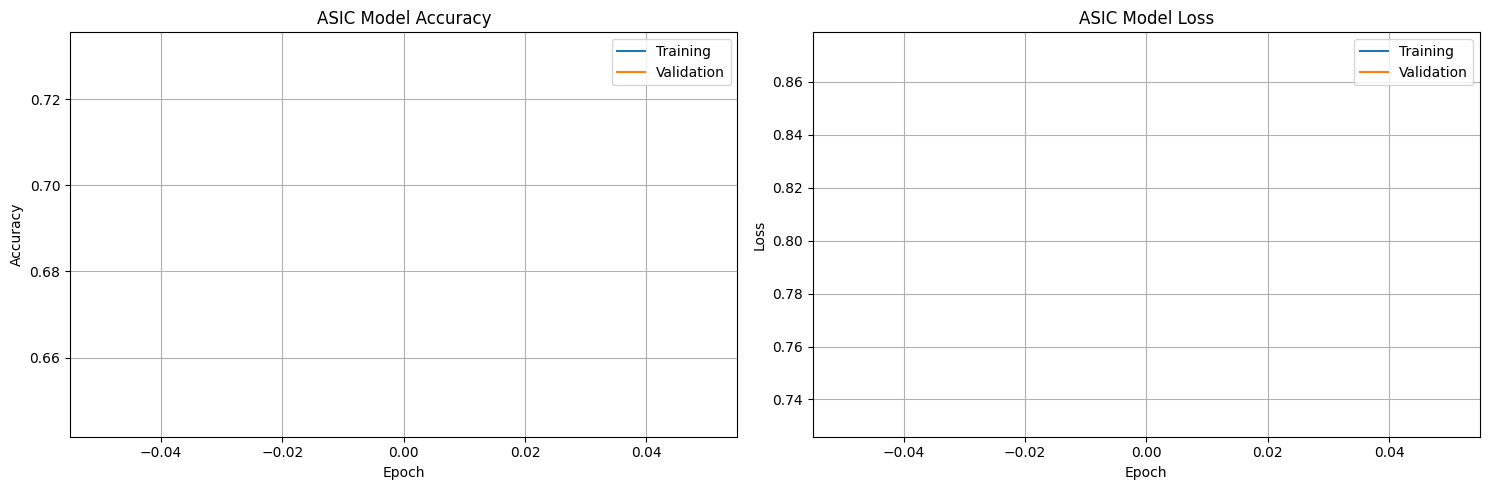

ROC curve plot saved to ASIC Model_results_20260605_114455/plots/4bit/ASIC Model_roc_curve.png


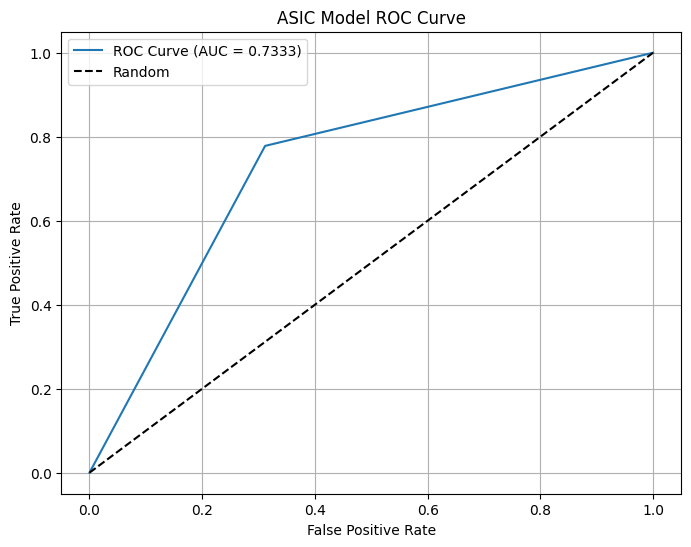


4. Results Summary:
Model Type      Bits     Accuracy   Loss       ROC AUC    BkgRej@90%   BkgRej@98%   BkgRej@99%  
------------------------------------------------------------------------------------------------------------------------
quantized       4        0.7333     0.7319     0.7333     0.0000       0.0000       0.0000      

BEST CONFIGURATION:
Model: quantized
Bits: 4-bit
Accuracy: 0.7333
ROC AUC: 0.7333

Results saved to: ASIC Model_results_20260605_114455/quantization_results.csv

=== ASIC Model Quantization Pipeline Completed! ===
All outputs saved to: ASIC Model_results_20260605_114455/
  - Models: ASIC Model_results_20260605_114455/models/
  - Plots: ASIC Model_results_20260605_114455/plots/
  - Results CSV: ASIC Model_results_20260605_114455/quantization_results.csv


[{'model_type': 'quantized',
  'weight_bits': 4,
  'integer_bits': 0,
  'test_accuracy': 0.733253538608551,
  'test_loss': 0.7319273948669434,
  'roc_auc': 0.7332535125672355,
  'bkg_rej_90pct': 0.0,
  'bkg_rej_98pct': 0.0,
  'bkg_rej_99pct': 0.0,
  'model_path': 'ASIC Model_results_20260605_114455/models/ASIC Model_quantized_4bit.h5'}]

In [3]:
# Model1.trainQuantizedModel(numEpochs=10)
Model1.runAllStuff(numEpochs=1,runUnquantized = False)

Evaluating ASIC Model [quantized_4w0i]...
 3/41 [=>............................] - ETA: 2s

/home/dabadjiev/miniconda3/envs/miscGithubEnviro/lib/python3.10/site-packages/keras/src/engine/functional.py:639: UserWarning: Input dict contained keys ['x_profile', 'cluster', 'nPix', 'x_local', 'nModule'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


41/41 [==============================] - 3s 80ms/step
Data rate at fpr 1.0 and threshold [0]
Data rate at fpr 1.0 and threshold [0]
Data rate at fpr 1.0 and threshold [0]
✓ ASIC Model evaluation completed!
  Test Loss: 0.4344
  Test Accuracy: 0.8118
  ROC AUC: 0.8118

  Background Rejection Metrics (Bkg Rej = 1 - FPR):
    @ 90% signal efficiency: Bkg Rej = 0.0000 (FPR = 1.000000), Back Data Accep = 0.1867
    @ 98% signal efficiency: Bkg Rej = 0.0000 (FPR = 1.000000), Back Data Accep = 0.1867
    @ 99% signal efficiency: Bkg Rej = 0.0000 (FPR = 1.000000), Back Data Accep = 0.1867
['nModule', 'z_global', 'y_local', 'x_local', 'nPix']


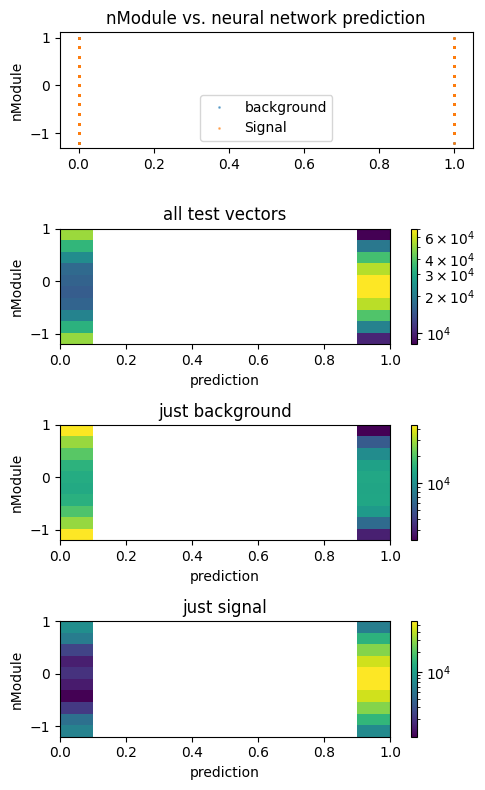

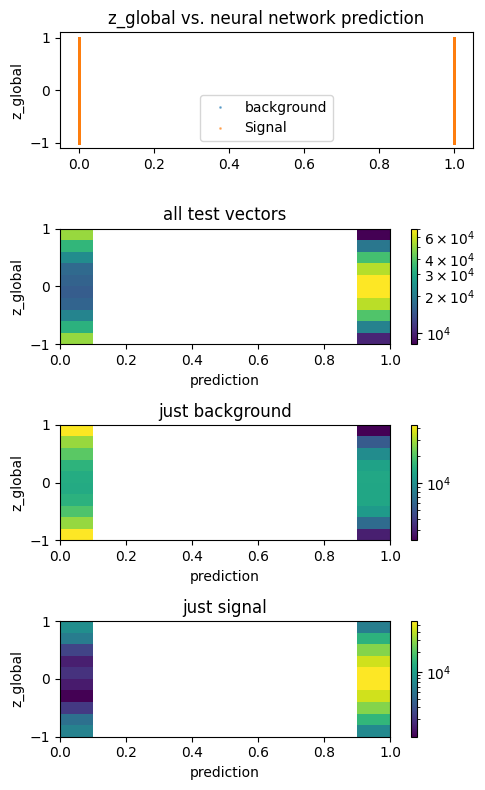

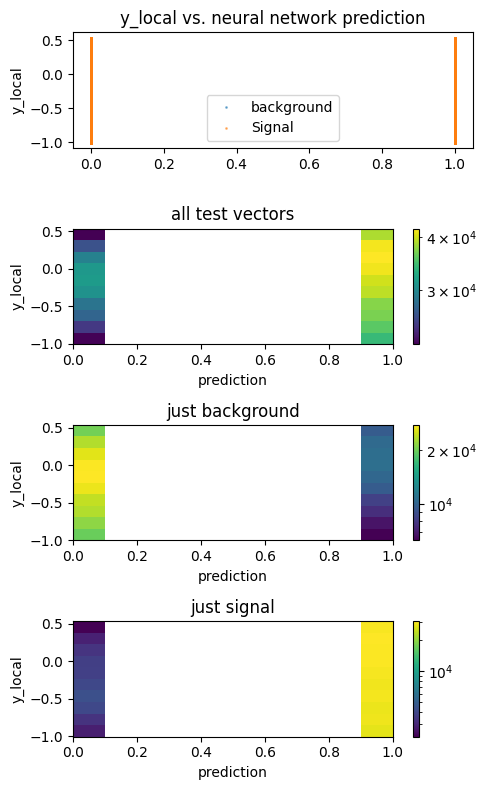

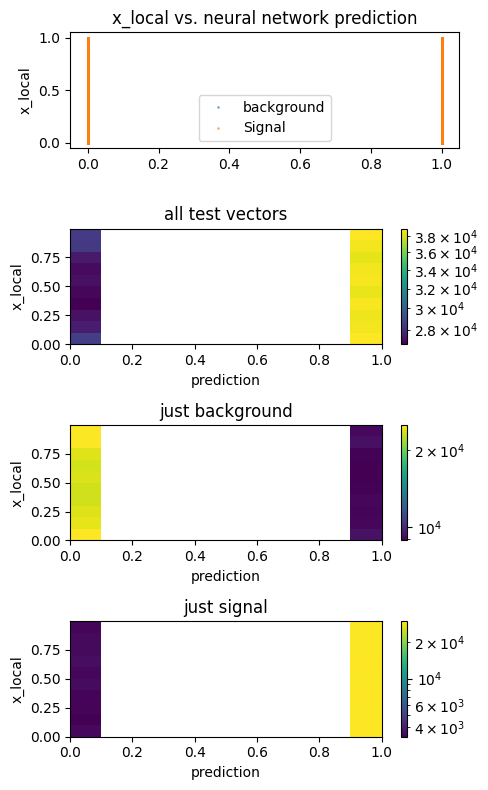

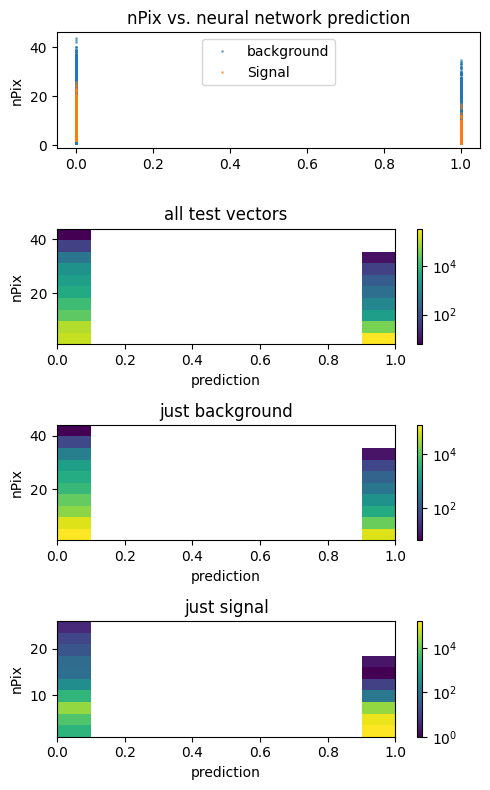

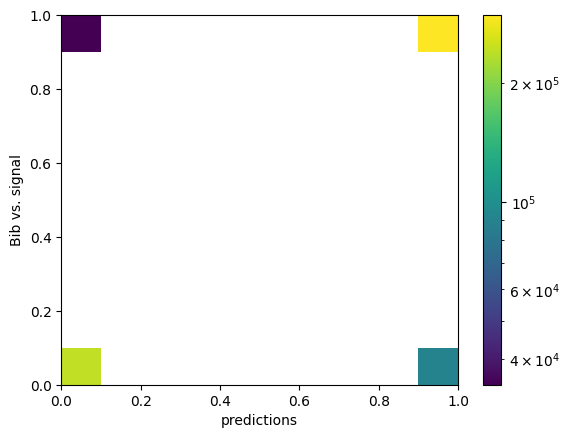

{'test_loss': 0.43441054224967957,
 'test_accuracy': 0.8117862343788147,
 'roc_auc': 0.8117862617576895,
 'fpr': [0.0, 0.27224021212973293, 1.0],
 'tpr': [0.0, 0.895812735645112, 1.0],
 'thresholds': [2, 1, 0],
 'bkg_rej_at_90pct': 0.0,
 'fpr_at_90pct': 1.0,
 'bkg_rej_at_98pct': 0.0,
 'fpr_at_98pct': 1.0,
 'bkg_rej_at_99pct': 0.0,
 'fpr_at_99pct': 1.0,
 'numBackPixesPostFilter': [373508.0, 373508.0, 373508.0],
 'numBackPixesTotal': [2000084.0, 2000084.0, 2000084.0],
 'numBackPixesRejRatio': [0.18674615, 0.18674615, 0.18674615]}

In [4]:
Model1.evaluate(config_name="quantized_4w0i",predictionPlots=True)

In [4]:
predictions = Model1.models["quantized_4w0i"].predict(Model1.validation_generator, verbose=1)
# predictions = Model1.models["Unquantized"].predict(Model1.validation_generator, verbose=1)
import numpy as np
true_labels = np.concatenate([y for _, y in Model1.validation_generator])

if predictions.shape[1]>1:
    predictions = np.argmax(predictions,axis=1)

 3/41 [=>............................] - ETA: 2s

/home/dabadjiev/miniconda3/envs/miscGithubEnviro/lib/python3.10/site-packages/keras/src/engine/functional.py:639: UserWarning: Input dict contained keys ['x_profile', 'cluster', 'nPix', 'x_local', 'nModule'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


41/41 [==============================] - 3s 83ms/step


In [5]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(true_labels, predictions.ravel())

In [4]:
Model1.models["quantized_4w0i"].save("./model1Test4hls.h5")

/home/dabadjiev/miniconda3/envs/miscGithubEnviro/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [5]:
# %pip install particle
import varPredPlotUtils
filepath = "./model1Test4hls.h5"
from Model_Classes import GradientMonitor, WarmupThenDecay
co = {"GradientMonitor": GradientMonitor, "WarmupThenDecay": WarmupThenDecay}
quantizedModel = varPredPlotUtils.loadQModel(filepath,None,co=co) # get ValueError: Unknown decay: 'WarmupThenDecay'. Please ensure you are using a `keras.utils.custom_object_scope` and that this object is included in the scope. See https://www.tensorflow.org/guide/keras/save_and_serialize#registering_the_custom_object for details.
# quantizedModel = Model1.models["quantized_4w0i"]
model, predictions,modelType = varPredPlotUtils.getModelAndPredict(quantizedModel)

Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


/home/dabadjiev/miniconda3/envs/miscGithubEnviro/lib/python3.10/site-packages/keras/src/engine/functional.py:639: UserWarning: Input dict contained keys ['x_profile', 'cluster', 'nPix', 'x_local', 'nModule'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


Training generator length: 162
Validation generator length: 41
Evaluating ASIC Model [justThisOne]...
41/41 [==============================] - 3s 74ms/step
Data rate at fpr 1.0 and threshold [0]
Data rate at fpr 1.0 and threshold [0]
Data rate at fpr 1.0 and threshold [0]
✓ ASIC Model evaluation completed!
  Test Loss: 0.7319
  Test Accuracy: 0.7333
  ROC AUC: 0.7333

  Background Rejection Metrics (Bkg Rej = 1 - FPR):
    @ 90% signal efficiency: Bkg Rej = 0.0000 (FPR = 1.000000), Back Data Accep = 0.1718
    @ 98% signal efficiency: Bkg Rej = 0.0000 (FPR = 1.000000), Back Data Accep = 0.1718
    @ 99% signal efficiency: Bkg Rej = 0.0000 (FPR = 1.000000), Back Data Accep = 0.1718
41/41 [==============================] - 3s 73ms/step
